# MCMC in Transformed Spaces

NUTS (No-U-Turn Sampler) works best in **unconstrained spaces** — all of ℝⁿ. But model parameters often live in constrained spaces:

- Standard deviation `σ > 0`
- PRF position bounded to screen `x ∈ [−10, 10]`
- Stimulus angle `θ ∈ [0, 2π]`

The solution is to:
1. Transform to unconstrained space, sample there
2. Include a **Jacobian correction** so the resulting posterior is correct
3. Transform samples back to the original space

This notebook shows exactly why the Jacobian matters and how to do it right with [Blackjax](https://blackjax-devs.github.io/blackjax/).

In [15]:
import jax
import jax.numpy as jnp
import blackjax
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

jax.config.update('jax_enable_x64', True)

## 1. The Problem: Constrained Parameters

Suppose we observe data `y ~ Normal(μ, σ)` and want the posterior over `(μ, σ)`. The catch: `σ > 0`.

If we just hand NUTS unconstrained `σ`, it will happily wander into negative territory and break.

**Standard trick:** define `φ = log(σ)` which lives on all of ℝ. Sample `φ`, then recover `σ = exp(φ)`.

But we need to be careful about what distribution we're actually sampling from.

In [16]:
# Simulate data — deliberately few observations so σ is uncertain
true_mu    = 3.0
true_sigma = 2.0   # large σ → posterior spans a wide log-range

rng = np.random.default_rng(42)
y = rng.normal(true_mu, true_sigma, size=5).astype(np.float64)  # only 5 obs!

n = len(y)
mu_hat    = y.mean()
sigma_hat = y.std(ddof=1)
print(f'Sample mean:  {mu_hat:.3f}  (true: {true_mu})')
print(f'Sample sigma: {sigma_hat:.3f}  (true: {true_sigma})')
print(f'n = {n}  ← small sample → wide posterior → Jacobian matters')

Sample mean:  2.602  (true: 3.0)
Sample sigma: 2.496  (true: 2.0)
n = 5  ← small sample → wide posterior → Jacobian matters


## 2. The Math: Change of Variables

We want samples from the **posterior** `p(μ, σ | y)`. We instead sample `(μ, φ)` where `φ = log(σ)`.

The change-of-variables formula tells us:

$$p(\mu, \varphi \mid y) = p(\mu, \sigma(\varphi) \mid y) \cdot \left|\frac{\partial \sigma}{\partial \varphi}\right|$$

In log-space (which is what we give NUTS):

$$\log p(\mu, \varphi \mid y) = \underbrace{\log p(y \mid \mu, e^\varphi)}_\text{log-likelihood} + \underbrace{\log p(\mu, e^\varphi)}_\text{log-prior} + \underbrace{\log\left|\frac{\partial \sigma}{\partial \varphi}\right|}_\text{log Jacobian}$$

For the log transform `σ = exp(φ)`:
$$\frac{\partial \sigma}{\partial \varphi} = e^\varphi = \sigma \quad \Rightarrow \quad \log\left|J\right| = \varphi$$

**If you skip the Jacobian**, NUTS samples from a *warped* distribution — the samples look like they're from the right space but the density is wrong. Peaks shift, tails distort.

## 3. Transforms and Their Log-Jacobians

Here are the transforms relevant to braincoder PRF fitting:

In [17]:
# Each transform is a (forward, inverse, log_det_jacobian) triple.
# forward:  unconstrained φ  →  constrained θ
# inverse:  constrained θ    →  unconstrained φ
# log_det_jacobian: log|∂θ/∂φ|  (scalar, summed over dimensions)

def exp_transform(phi):
    """φ ∈ ℝ  →  σ = exp(φ) > 0.  Log-Jacobian = φ."""
    theta = jnp.exp(phi)
    log_jac = jnp.sum(phi)       # log|exp(φ)| = φ
    return theta, log_jac

def softplus_transform(phi):
    """φ ∈ ℝ  →  σ = log(1+exp(φ)) > 0.  Log-Jacobian = log(sigmoid(φ))."""
    theta = jnp.log1p(jnp.exp(phi))
    log_jac = jnp.sum(-jnp.log1p(jnp.exp(-phi)))  # log(sigmoid(phi))
    return theta, log_jac

def bounded_sigmoid_transform(phi, low, high):
    """φ ∈ ℝ  →  θ = sigmoid(φ)*(high-low)+low ∈ [low, high]."""
    s = jax.nn.sigmoid(phi)
    theta = s * (high - low) + low
    log_jac = jnp.sum(jnp.log(high - low) + jnp.log(s) + jnp.log(1.0 - s))
    return theta, log_jac

# Inverses (needed to initialise NUTS in unconstrained space)
def exp_inverse(theta):              return jnp.log(theta)
def softplus_inverse(theta):         return jnp.log(jnp.exp(theta) - 1.0)
def bounded_sigmoid_inverse(theta, low, high):
    y = (theta - low) / (high - low)
    return jnp.log(y / (1.0 - y))

## 4. Run NUTS — WITH and WITHOUT Jacobian

We fit `μ ∈ ℝ` (no transform needed) and `σ > 0` via `exp` transform.

In [18]:
from tqdm.auto import tqdm

y_jax = jnp.array(y)

def make_log_prob(include_jacobian: bool):
    def log_prob(params):
        phi_mu    = params['phi_mu']
        phi_sigma = params['phi_sigma']

        mu    = phi_mu
        sigma, log_jac = exp_transform(phi_sigma)

        log_lik = jnp.sum(jax.scipy.stats.norm.logpdf(y_jax, mu, sigma))
        log_prior = (jax.scipy.stats.norm.logpdf(mu, 0.0, 10.0)
                   + jax.scipy.stats.expon.logpdf(sigma, scale=2.0))

        if include_jacobian:
            return log_lik + log_prior + log_jac
        else:
            return log_lik + log_prior

    return log_prob


def run_nuts(log_prob_fn, label='NUTS', n_warmup=200, n_samples=500, seed=0):
    rng_key = jax.random.PRNGKey(seed)

    init_params = {
        'phi_mu':    jnp.array(0.0),
        'phi_sigma': exp_inverse(jnp.array(1.0)),
    }

    warmup = blackjax.window_adaptation(blackjax.nuts, log_prob_fn, num_steps=n_warmup)
    rng_key, warmup_key = jax.random.split(rng_key)
    state, kernel, _ = warmup.run(warmup_key, init_params)

    @jax.jit
    def one_step(state, rng_key):
        new_state, _ = kernel(rng_key, state)
        return new_state, (new_state.position['phi_mu'], new_state.position['phi_sigma'])

    keys = jax.random.split(rng_key, n_samples)
    _, (phi_mu_samples, phi_sigma_samples) = jax.lax.scan(one_step, state, keys)

    mu_samples    = phi_mu_samples
    sigma_samples = jnp.exp(phi_sigma_samples)
    return mu_samples, sigma_samples


mu_correct, sigma_correct = run_nuts(make_log_prob(include_jacobian=True),  label='NUTS w/ Jacobian')
mu_wrong,   sigma_wrong   = run_nuts(make_log_prob(include_jacobian=False), label='NUTS w/o Jacobian')
print('Done.')

Done.


## 5. Compare — the Jacobian Matters

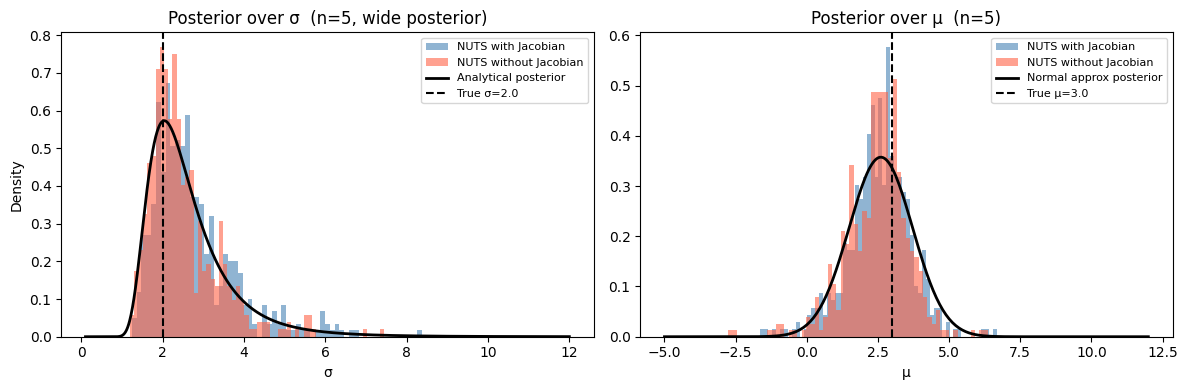

With Jacobian:    E[σ] = 2.7599,  E[μ] = 2.5417
Without Jacobian: E[σ] = 2.4940,  E[μ] = 2.4660
True values:             σ = 2.0,       μ = 3.0


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Reference: approximate analytical posterior for σ (scaled inverse-chi-squared)
# p(σ | y) ∝ σ^{-n-1} exp(-n*s^2 / (2*σ^2))  where s = sample std (MLE)
sigma_mle = y.std()
sigma_grid = np.linspace(0.1, 12.0, 1000)
log_post_sigma = -(n + 1) * np.log(sigma_grid) - n * sigma_mle**2 / (2 * sigma_grid**2)
post_sigma = np.exp(log_post_sigma - log_post_sigma.max())
post_sigma /= np.trapz(post_sigma, sigma_grid)

# --- sigma posterior ---
ax = axes[0]
ax.hist(np.array(sigma_correct), bins=60, density=True,
        alpha=0.6, color='steelblue', label='NUTS with Jacobian')
ax.hist(np.array(sigma_wrong), bins=60, density=True,
        alpha=0.6, color='tomato', label='NUTS without Jacobian')
ax.plot(sigma_grid, post_sigma, 'k-', lw=2, label='Analytical posterior')
ax.axvline(true_sigma, color='k', linestyle='--', label=f'True σ={true_sigma}')
ax.set_xlabel('σ')
ax.set_ylabel('Density')
ax.set_title('Posterior over σ  (n=5, wide posterior)')
ax.legend(fontsize=8)

# --- mu posterior ---
mu_grid = np.linspace(-5, 12, 300)
# With unknown σ this is a t-distribution; approximate with normal for reference
post_mu = stats.norm.pdf(mu_grid, mu_hat, sigma_hat / np.sqrt(n))

ax = axes[1]
ax.hist(np.array(mu_correct), bins=60, density=True,
        alpha=0.6, color='steelblue', label='NUTS with Jacobian')
ax.hist(np.array(mu_wrong), bins=60, density=True,
        alpha=0.6, color='tomato', label='NUTS without Jacobian')
ax.plot(mu_grid, post_mu, 'k-', lw=2, label='Normal approx posterior')
ax.axvline(true_mu, color='k', linestyle='--', label=f'True μ={true_mu}')
ax.set_xlabel('μ')
ax.set_title('Posterior over μ  (n=5)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'With Jacobian:    E[σ] = {sigma_correct.mean():.4f},  E[μ] = {mu_correct.mean():.4f}')
print(f'Without Jacobian: E[σ] = {sigma_wrong.mean():.4f},  E[μ] = {mu_wrong.mean():.4f}')
print(f'True values:             σ = {true_sigma},       μ = {true_mu}')

## 6. What Happened Without the Jacobian?

Without the Jacobian, NUTS samples from:
$$\tilde{p}(\mu, \varphi \mid y) \propto p(y \mid \mu, e^\varphi) \cdot p(\mu, e^\varphi)$$

This is the posterior over `(μ, φ)`, **not** `(μ, σ)`. When you push those `φ` samples through `exp()`, you get a distribution over `σ` that is systematically shifted — the probability mass doesn't transform correctly.

Concretely: the mode of `p(φ | y)` in `φ`-space is `φ* = log(σ*)`, but the mode of `p(σ | y)` in `σ`-space is **not** at `σ* = exp(φ*)`. The Jacobian `|∂σ/∂φ| = σ` pushes the mode rightward — larger `σ` values have more volume and get upweighted.

Without the correction, the posterior over `σ` will be **biased toward smaller values**.

## 7. Recovering the Original-Space Distribution

Once you have NUTS samples in the **unconstrained space** `φ`, recovering the constrained distribution is just applying the forward transform:

```python
# NUTS gives you: phi_sigma samples in ℝ
phi_sigma_samples = ...   # shape (n_samples,)

# Transform back to original space:
sigma_samples = jnp.exp(phi_sigma_samples)   # now > 0
```

These `sigma_samples` are genuine posterior samples from `p(σ | y)` — no extra adjustment needed beyond the transform. The Jacobian correction in the log_prob already ensured the NUTS chain targeted the right distribution.

You can compute posterior statistics directly:
```python
posterior_mean   = sigma_samples.mean()
posterior_std    = sigma_samples.std()
credible_interval = jnp.percentile(sigma_samples, jnp.array([2.5, 97.5]))
```

In [20]:
print('Posterior summaries (with Jacobian correction):')
print(f'  μ:  mean={mu_correct.mean():.4f}, std={mu_correct.std():.4f}, '
      f'95% CI=[{jnp.percentile(mu_correct, 2.5):.4f}, {jnp.percentile(mu_correct, 97.5):.4f}]')
print(f'  σ:  mean={sigma_correct.mean():.4f}, std={sigma_correct.std():.4f}, '
      f'95% CI=[{jnp.percentile(sigma_correct, 2.5):.4f}, {jnp.percentile(sigma_correct, 97.5):.4f}]')
print(f'\nTrue values: μ={true_mu}, σ={true_sigma}')

Posterior summaries (with Jacobian correction):
  μ:  mean=2.5417, std=1.0964, 95% CI=[0.2005, 4.5262]
  σ:  mean=2.7599, std=1.0333, 95% CI=[1.5119, 5.8581]

True values: μ=3.0, σ=2.0


## 8. Bounded Parameters — Jacobian matters most near the boundary

For parameters with both lower and upper bounds (e.g. stimulus x-position on a screen), use the **bounded sigmoid** transform. The Jacobian is `log((b−a)·σ·(1−σ))` where σ = sigmoid(φ). 

Near the boundary (e.g. x close to 9 out of [−10, 10]), σ ≈ 1 and log(1−σ) → −∞. The Jacobian correction is enormous there — without it, NUTS is strongly biased away from the boundary.

w/ Jacobian: warmup... sampling... done.
w/o Jacobian: warmup... sampling... done.


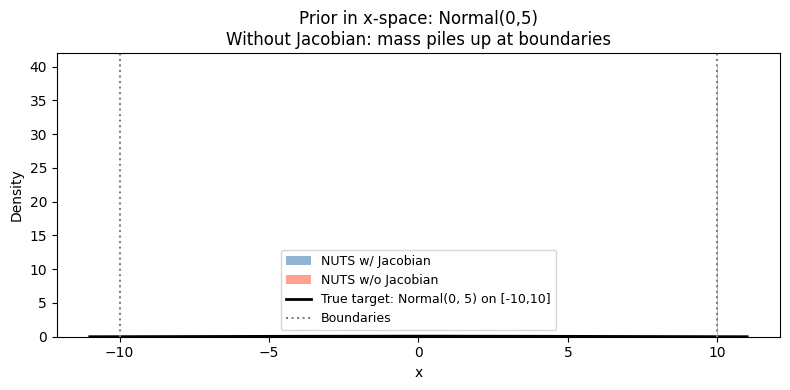

With Jacobian:    E[x]=0.22, std=4.19
Without Jacobian: E[x]=10.00, std=0.00  ← biased toward boundaries


In [21]:
low, high = -10.0, 10.0

# Prior is defined on x (constrained space): Normal(0, 5).
# With Jacobian:    x ~ Normal(0, 5) truncated to [-10,10]  — correct, bell-shaped
# Without Jacobian: x ~ Normal(0, 5) / Jac — Jac→0 at boundaries, so density PILES UP there
def make_log_prob_bounded(include_jacobian: bool):
    def log_prob(params):
        phi_x = params['phi_x']
        x, log_jac = bounded_sigmoid_transform(phi_x, low, high)
        log_prior_x = jax.scipy.stats.norm.logpdf(x, 0.0, 5.0)   # prior in x-space
        return (log_prior_x + log_jac) if include_jacobian else log_prior_x
    return log_prob

def run_nuts_bounded(log_prob_fn, label, n_warmup=200, n_samples=1000, seed=0):
    rng_key = jax.random.PRNGKey(seed)
    init = {'phi_x': jnp.array(0.0)}
    warmup = blackjax.window_adaptation(blackjax.nuts, log_prob_fn, num_steps=n_warmup)
    rng_key, wk = jax.random.split(rng_key)
    print(f'{label}: warmup...', end=' ', flush=True)
    state, kernel, _ = warmup.run(wk, init)

    @jax.jit
    def one_step(state, rng_key):
        new_state, _ = kernel(rng_key, state)
        return new_state, new_state.position['phi_x']

    keys = jax.random.split(rng_key, n_samples)
    print('sampling...', end=' ', flush=True)
    _, phi_samples = jax.lax.scan(one_step, state, keys)
    print('done.')
    x_samples, _ = jax.vmap(lambda p: bounded_sigmoid_transform(p, low, high))(phi_samples)
    return x_samples

x_correct = run_nuts_bounded(make_log_prob_bounded(True),  label='w/ Jacobian')
x_wrong   = run_nuts_bounded(make_log_prob_bounded(False), label='w/o Jacobian')

# Reference: truncated Normal(0, 5) on [-10, 10]
x_grid = np.linspace(-11, 11, 500)
ref = stats.truncnorm.pdf(x_grid, a=(low-0)/5, b=(high-0)/5, loc=0, scale=5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.array(x_correct), bins=40, density=True, alpha=0.6, color='steelblue', label='NUTS w/ Jacobian')
ax.hist(np.array(x_wrong),   bins=40, density=True, alpha=0.6, color='tomato',    label='NUTS w/o Jacobian')
ax.plot(x_grid, ref, 'k-', lw=2, label='True target: Normal(0, 5) on [-10,10]')
ax.axvline(low,  color='gray', linestyle=':', lw=1.5)
ax.axvline(high, color='gray', linestyle=':', lw=1.5, label='Boundaries')
ax.set_xlabel('x'); ax.set_ylabel('Density')
ax.set_title('Prior in x-space: Normal(0,5)\nWithout Jacobian: mass piles up at boundaries')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'With Jacobian:    E[x]={x_correct.mean():.2f}, std={x_correct.std():.2f}')
print(f'Without Jacobian: E[x]={x_wrong.mean():.2f}, std={x_wrong.std():.2f}  ← biased toward boundaries')

## 9. Circular / Periodic Parameters (e.g. stimulus angle)

For angles, the `exp` and `sigmoid` tricks don't work — the parameter space is a circle, not an interval. The right approach is to **parameterise via (sin, cos)** and reconstruct the angle:

```python
# Instead of sampling angle θ ∈ [0, 2π] directly,
# sample (s, c) ∈ ℝ² and normalise:
def angle_transform(phi_s, phi_c):
    norm = jnp.sqrt(phi_s**2 + phi_c**2)
    theta = jnp.arctan2(phi_s / norm, phi_c / norm)  # ∈ (-π, π]
    return theta
```

This avoids the discontinuity problem of modulo-based wrapping. The Jacobian of `arctan2` on the unit circle is 1 (constant), so no correction needed — though the normalisation step makes gradient computation via autodiff non-trivial. 

**Simpler alternative for smooth posteriors:** just sample `φ ∈ ℝ` unconstrained and apply `θ = φ mod 2π` only at the end when reading out samples, never inside the log_prob. This works fine when the posterior doesn't wrap around (unimodal on the circle).

## 10. Summary

| Parameter constraint | Transform | Inverse | log\|J\| |
|---|---|---|---|
| `σ > 0` | `exp(φ)` | `log(θ)` | `φ` |
| `σ > 0` (softer) | `softplus(φ)` | `softplus_inv(θ)` | `log(sigmoid(φ))` |
| `θ ∈ [a, b]` | `sigmoid(φ)*(b−a)+a` | `logit((θ−a)/(b−a))` | `log((b−a)·s·(1−s))` |
| `θ ∈ ℝ` | identity | identity | `0` |
| `θ ∈ [0, 2π]` | `arctan2(sin,cos)` | — | `0` (approx) |

**Key rules:**
1. Always include `log_det_jacobian` inside the `log_prob` you pass to NUTS — not afterwards.
2. After sampling, apply `forward(phi_samples)` to get samples in the original space. No further adjustment needed.
3. All posterior statistics (mean, std, credible intervals) are computed on the transformed-back samples.